In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


\begin{align}
  A \rightarrow&\; B,&\; &k_1 = 0.04 \\
  B + B \rightarrow&\; C + B,&\; &k_2 = 3e7 \\
  B + C \rightarrow&\; A + C,&\; &k_3 = 1e4 \\
\end{align}

\begin{align}
  \frac{\partial [A]}{\partial t} =&\; -k_1 [A] + k_3[B][C] \\
  \frac{\partial [B]}{\partial t} =&\; k_1[A] -2k_2 [B]^2 +k_2[B]^2 - k_3[B][C] = k_1[A] -k_2 [B]^2 - k_3[B][C] \\
  \frac{\partial [C]}{\partial t} =&\; k_2 [B]^2 -k_3[B][C] + k_3[B][C] = k_2[B]^2\\
\end{align}

\begin{align}
  \dot{x_1} =&\; -k_1x_1 + k_3x_2x_3 \\
  \dot{x_2} =&\; k_1x_1 -k_2 x_2^2 - k_3x_2x_3 \\
  \dot{x_3} =&\; k_2 x_2^2 \\
\end{align}


In [2]:
true = pd.read_csv('build/robertson_analytical_concentrations.csv', index_col='time')

In [34]:
relative_errors = []
absolute_differences = []
for i in range(1, 34):
    robert = pd.read_csv(f'build/robertson_model_concentrations_{i}.csv', index_col='time')
    absolute_difference = (true - robert).abs()
    relative_error = absolute_difference / true
    relative_errors.append(relative_error)
    absolute_differences.append(absolute_difference)

In [35]:
min_tolerance_power = 2
max_tolerance_power = 10
tolerance_factor_power = 4
num_tolerance_loops = (max_tolerance_power - min_tolerance_power) * tolerance_factor_power + 1
start_tolerance = np.power(0.1, min_tolerance_power)
tolerance_factor = np.power(0.1, 1.0 / tolerance_factor_power)

labels = []
for tolerance_loop in range(1, num_tolerance_loops + 1):
    relative_tolerance = start_tolerance
    absolute_tolerance = 1.0e-6 * relative_tolerance
    labels.append(f'{relative_tolerance:.1e}, {absolute_tolerance:.1e}')
    start_tolerance *= tolerance_factor

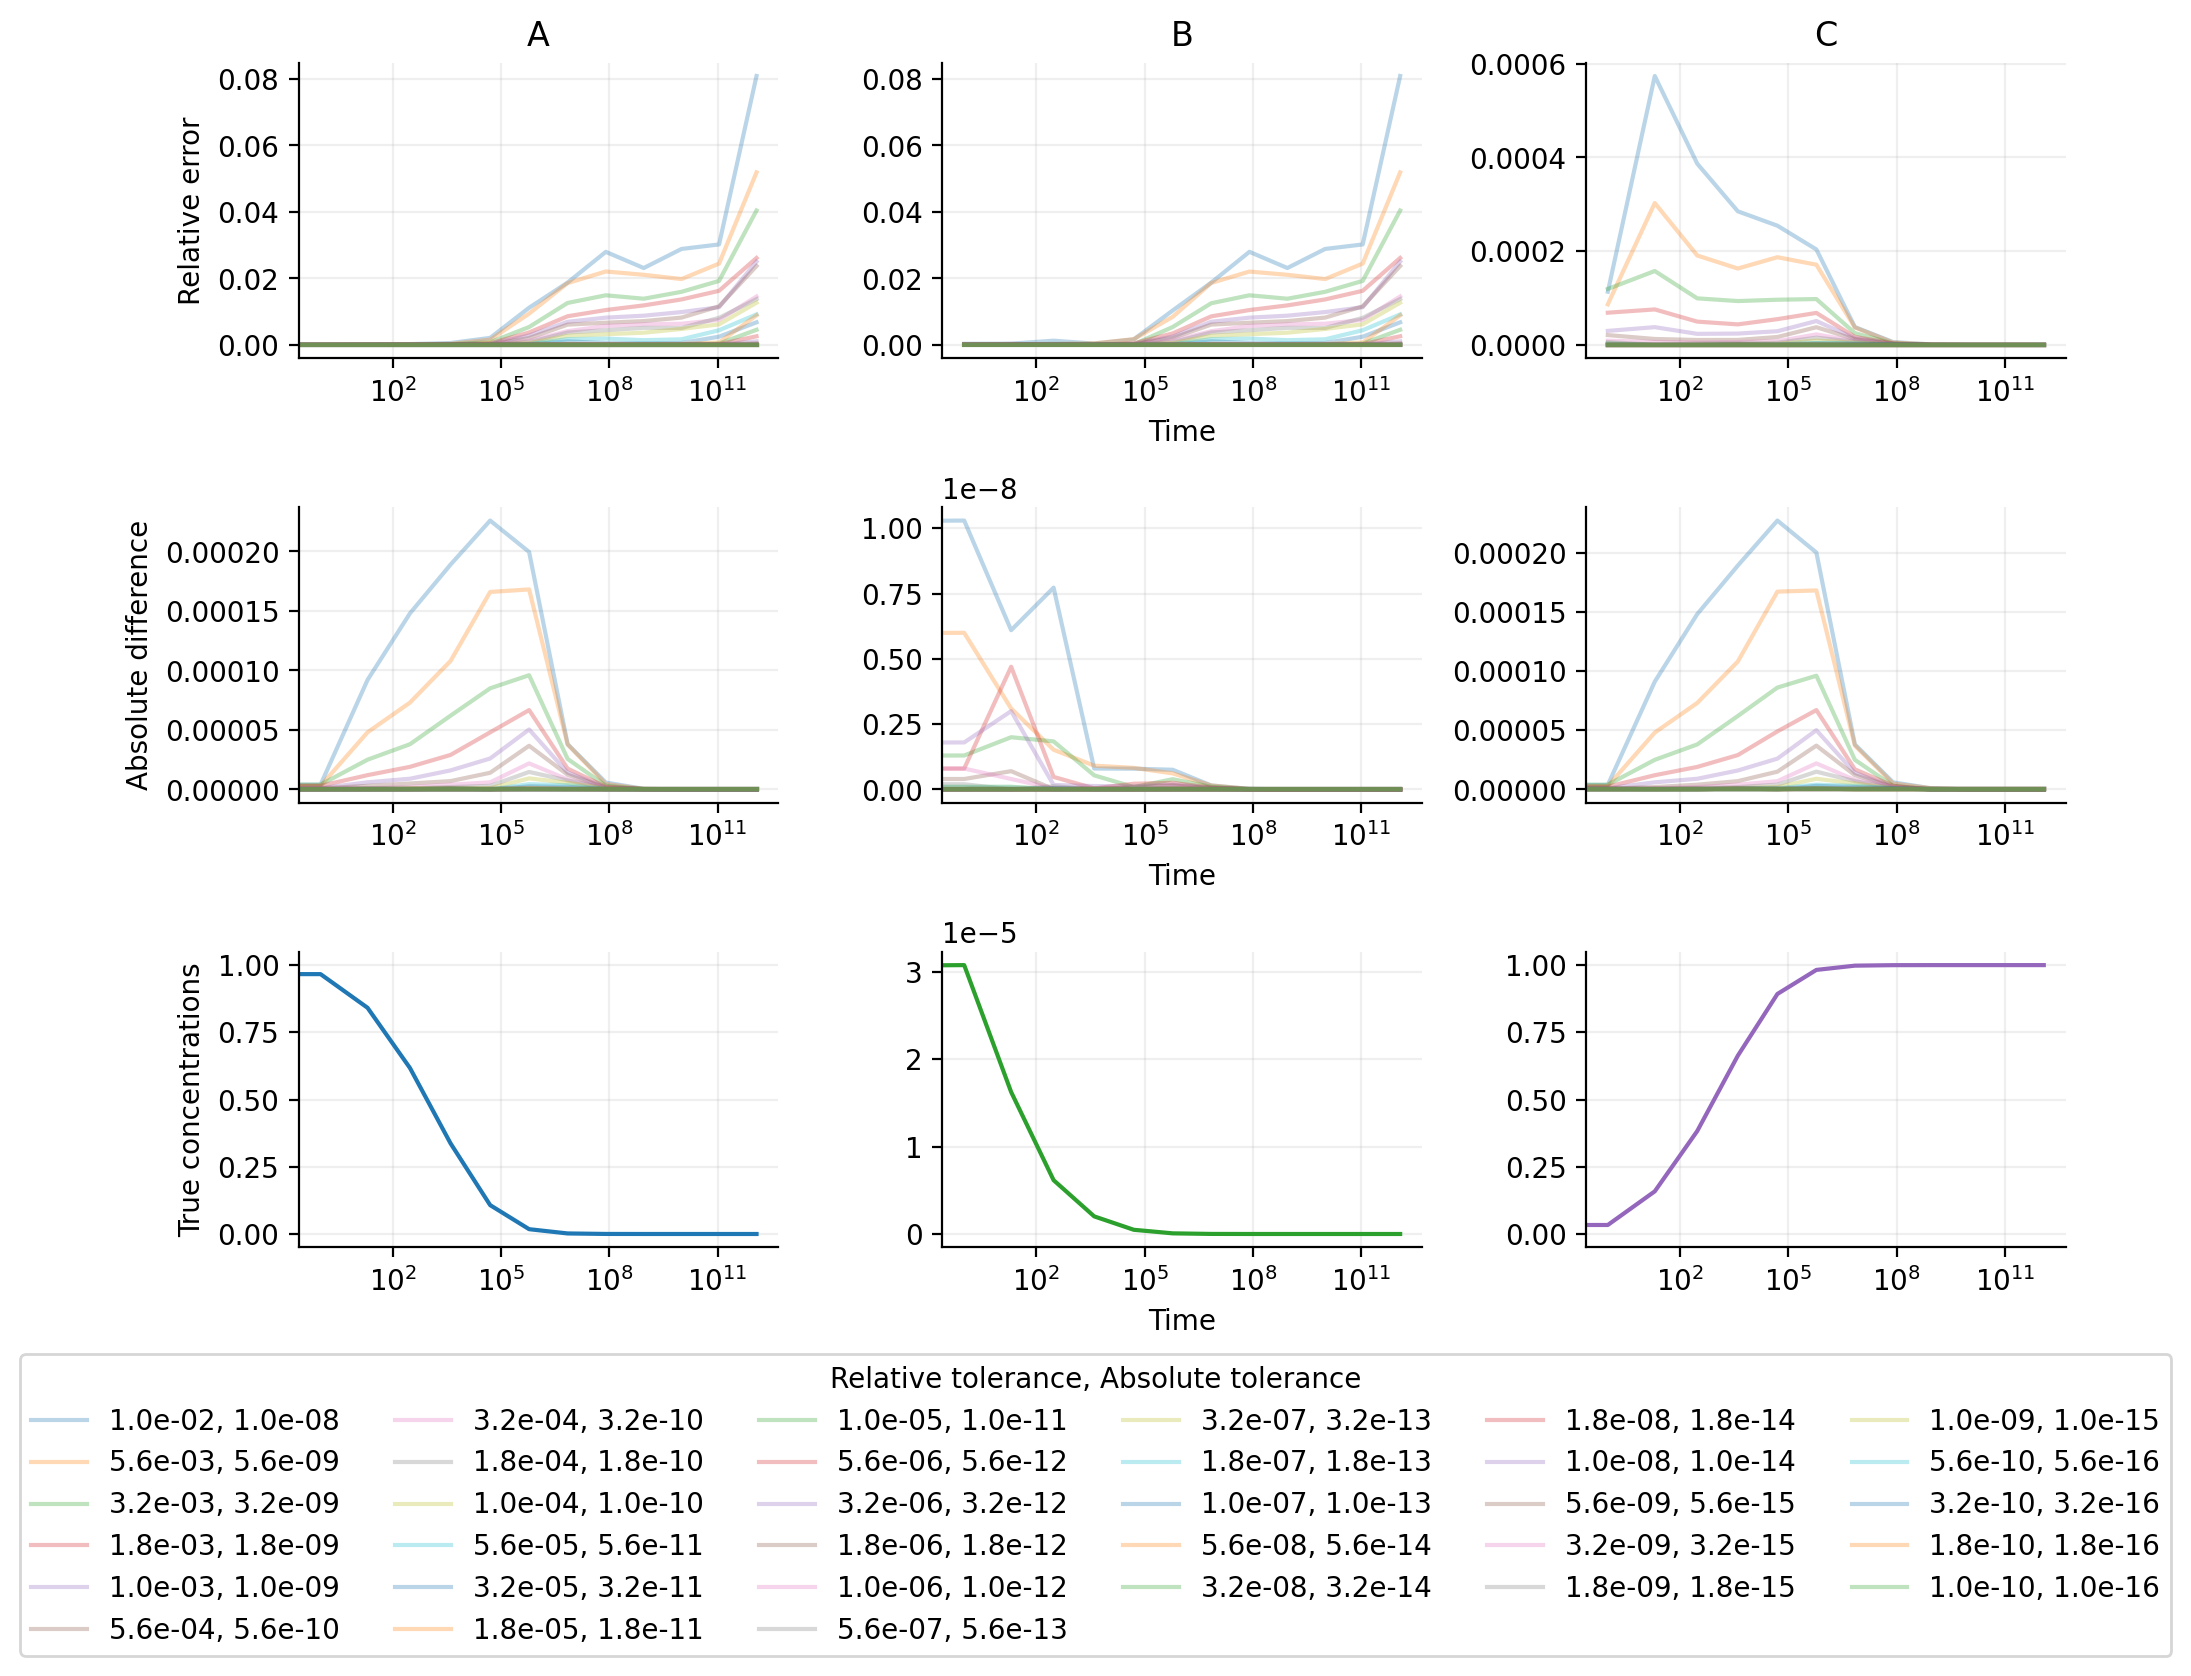

In [37]:
fig, axes = plt.subplots(3,3, figsize=[10, 8], dpi=200)

start = 0
for i in range(33):
    relative_errors[i]['A'].iloc[start:].plot(ax=axes[0][0], alpha=0.3)
    relative_errors[i]['B'].iloc[start:].plot(ax=axes[0][1], alpha=0.3)
    relative_errors[i]['C'].iloc[start:].plot(ax=axes[0][2], alpha=0.3)

    absolute_differences[i]['A'].iloc[start:].plot(ax=axes[1][0], alpha=0.3)
    absolute_differences[i]['B'].iloc[start:].plot(ax=axes[1][1], alpha=0.3)
    absolute_differences[i]['C'].iloc[start:].plot(ax=axes[1][2], alpha=0.3)

true['A'].iloc[start:].plot(ax=axes[2][0], color='tab:blue')
true['B'].iloc[start:].plot(ax=axes[2][1], color='tab:green')
true['C'].iloc[start:].plot(ax=axes[2][2], color='tab:purple')

for ax in axes.ravel():
    ax.spines[:].set_visible(False)
    ax.spines['left'].set_visible(True)
    ax.spines['bottom'].set_visible(True)
    ax.set_xscale('log')
    ax.set_xlabel('')
    ax.grid(True, alpha=0.2)

axes[0][0].set_title('A')
axes[0][1].set_title('B')
axes[0][2].set_title('C')
axes[0][0].set_ylabel('Relative error')
axes[1][0].set_ylabel('Absolute difference')
axes[2][0].set_ylabel('True concentrations')
axes[0][1].set_xlabel('Time')
axes[1][1].set_xlabel('Time')
axes[2][1].set_xlabel('Time')

handles, _ = axes[0][0].get_legend_handles_labels()
fig.legend(handles, labels, loc='lower center', ncol=6, bbox_to_anchor=(0.5, -0.05), title='Relative tolerance, Absolute tolerance')

fig.tight_layout(rect=[0, 0.14, 1, 1])
fig.savefig('/Users/kshores/Desktop/three_stage_reset_contribution.png')